This script works on addressing need to get estimates of % O3 produced versus imported

In [14]:
import os
import glob
import fnmatch

import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point, Polygon

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt # Core library for plotting
import matplotlib.cm as cm # To use different colormaps
import cartopy.crs as ccrs # For map projection
import seaborn as sns # boxplot


/home/taoma528/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [15]:
# !pip install geopandas

In [16]:
import sys
sys.path.insert(0,'/home/taoma528/Scripts/CESM_analysis/functions/')

from Plot_2D import Plot_2D # To draw a map

SCRIP_CONUS = '/home/taoma528/Scripts/CESM_analysis/functions/ne0CONUS_ne30x8_np4_SCRIP.nc'
SCRIP_ne30 = '/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons.nc'

Download the shape files   
Website: https://www.census.gov/geographies/mapping-files/time-series/geo/carto-boundary-file.html
 
Copied to Svante: rsync -avz --exclude=".*" -e ssh /Users/$USER/Downloads/USCensus/* "taoma528@svante9.mit.edu:/home/taoma528/HelpfulFiles/USCensus2018/"

Unzip use unzip_to_folder.sh in the Helpful US Census 2018 folder with chmod +x unzip_to_folder.sh

./unzip_to_folder.sh yourfile.zip

In [17]:
def molecules_to_kg_per_m2_per_s(molecules_per_cm2_per_s, molecular_weight):
    """
        Read in emissions data in [molecules cm-2 s-1], and molecular_weight in [g/mole]
        Return emissions in [kg m-2 s-1]    
    """
    # Constants
    avogadro_number = 6.022e23  # molecules per mole
    m2_to_cm2 = 1e4  # square meters to square centimeters 
    kg_to_g = 1e3

    # Convert 
    kg_per_m2_per_s = molecules_per_cm2_per_s*(1/avogadro_number)*molecular_weight*(1/kg_to_g)*(m2_to_cm2)

    return kg_per_m2_per_s

# # Example usage
# molecules_per_cm2_per_s = 1  # for example, 1e18 molecules per cm^2 per second
# molecular_weight = 30  # molecular weight of water in g/mol

# result = molecules_to_kg_per_m2_per_s(molecules_per_cm2_per_s, molecular_weight)
# print("Result:", result, "kg/m^2/s")


setunit = r'$kg$ $m^{-2}s^{-1}$'

# Set up the shape file

In [29]:
### Geo information for boundaries
from shapely.geometry import Point
import numpy as np
import xarray as xr
import geopandas as gpd
import geopandas as gpd

USCensus_diri = '/home/taoma528/HelpfulFiles/USCensus2018/'

# # Path to the shapefile (adjust if the file is inside a folder)
# shapefile_path = '/home/taoma528/HelpfulFiles/world-administrative-boundaries/world-administrative-boundaries.shp'

# # Read shapefile directly
# gdf = gpd.read_file(shapefile_path)

# # # Preview
# # print(gdf.columns)
# # print(gdf.head())

# # Adjust based on the actual column names (use print(gdf.columns) to confirm)
# us_boundary = gdf[(gdf['status'] == 'Member State')&(gdf['name'] == 'United States of America')]  # or 'USA', depending on the file

# # Create a GeoDataFrame
# us_gdf = gpd.GeoDataFrame(us_boundary, geometry='geometry')



In [30]:
shapefile_path = f'{USCensus_diri}cb_2018_us_state_500k/cb_2018_us_state_500k.shp'
print(shapefile_path)

gdf = gpd.read_file(shapefile_path)
# Print basic information
print(gdf.info())           # Column names, data types, non-null counts
# print(gdf.head())           # Preview the first few rows
# print(gdf.columns)          # List all column names
# print(gdf.crs)              # Coordinate reference system (CRS)
# print(gdf.geometry.name)    # Name of the geometry column
# print(gdf.geometry.type.unique())  # Geometry types (e.g., Polygon, MultiPolygon)

# Optional: plot a quick map
# gdf.plot()


/home/taoma528/HelpfulFiles/USCensus2018/cb_2018_us_state_500k/cb_2018_us_state_500k.shp
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   56 non-null     object  
 1   STATENS   56 non-null     object  
 2   AFFGEOID  56 non-null     object  
 3   GEOID     56 non-null     object  
 4   STUSPS    56 non-null     object  
 5   NAME      56 non-null     object  
 6   LSAD      56 non-null     object  
 7   ALAND     56 non-null     int64   
 8   AWATER    56 non-null     int64   
 9   geometry  56 non-null     geometry
dtypes: geometry(1), int64(2), object(7)
memory usage: 4.5+ KB
None


In [31]:
# gdf = gpd.read_file(shapefile_path)
# gdf

In [98]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the shapefile
shapefile_path = "/home/taoma528/HelpfulFiles/USCensus2018/cb_2018_us_state_500k/cb_2018_us_state_500k.shp"
gdf = gpd.read_file(shapefile_path)

# Filter to lower 48 states
exclude = ['AK', 'HI', 'PR', 'GU', 'VI', 'MP', 'AS']
gdf_lower48 = gdf[~gdf['STUSPS'].isin(exclude)]

# Project to an equal-area CRS for buffering
gdf_proj = gdf_lower48.to_crs(epsg=5070)

# Merge and buffer
merged_shape = gdf_proj.unary_union
# buffered_shape = merged_shape.buffer(100000)  # 100 km
buffered_shape = merged_shape.buffer(80000)  # 80 km

# Create a GeoDataFrame for plotting
gdf_buffered = gpd.GeoDataFrame(geometry=[buffered_shape], crs=gdf_proj.crs)

# Reproject both back to geographic for consistent plotting
gdf_lower48 = gdf_lower48.to_crs(epsg=4326)
gdf_buffered = gdf_buffered.to_crs(epsg=4326)


### To make sure there is no hole
from shapely.geometry import Polygon, MultiPolygon

def remove_holes(geometry):
    if isinstance(geometry, Polygon):
        return Polygon(geometry.exterior)
    elif isinstance(geometry, MultiPolygon):
        return MultiPolygon([Polygon(p.exterior) for p in geometry.geoms])
    else:
        return geometry  # return as-is if not polygonal

# Apply hole removal to your geometry
geometry_no_holes = remove_holes(gdf_buffered.iloc[0].geometry)

# Update gdf_buffered
gdf_buffered['geometry'] = [geometry_no_holes]


/tmp/ipykernel_505/533564486.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  merged_shape = gdf_proj.unary_union


In [60]:
gdf_buffered

,geometry
0,"POLYGON ((-125.54203 40.17276, -125.54685 40.1..."


In [61]:
gdf_buffered

,geometry
0,"POLYGON ((-125.54203 40.17276, -125.54685 40.1..."


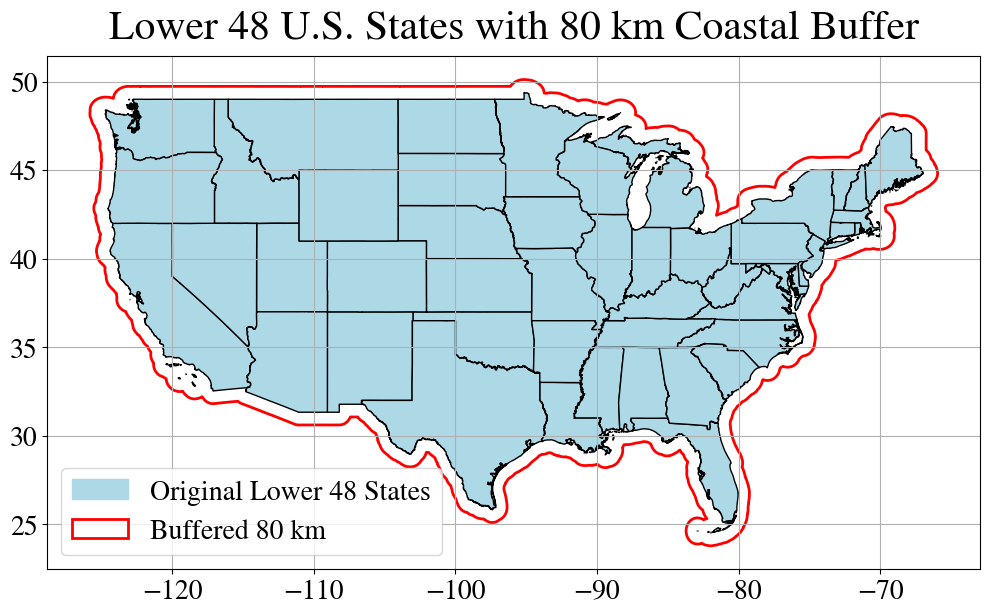

In [99]:
import matplotlib.patches as mpatches

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
gdf_lower48.plot(ax=ax, color='lightblue', edgecolor='black')
gdf_buffered.plot(ax=ax, color='none', edgecolor='red', linewidth=2)

# Create custom legend handles
original_patch = mpatches.Patch(color='lightblue', label='Original Lower 48 States')
buffer_patch = mpatches.Patch(edgecolor='red', facecolor='none', linewidth=2, label='Buffered 80 km')

plt.legend(handles=[original_patch, buffer_patch], loc='lower left',fontsize=20,)
plt.title("Lower 48 U.S. States with 80 km Coastal Buffer", fontsize=30, y=1.02)
plt.grid(True)

# Enlarge tick label font size
ax.tick_params(axis='both', which='major', labelsize=20)

# Tighten the layout
plt.tight_layout()

# Save the figure
# plt.savefig(savefig_filename, dpi=400, bbox_inches='tight')  # Adjust the filename and dpi as needed

plt.show()


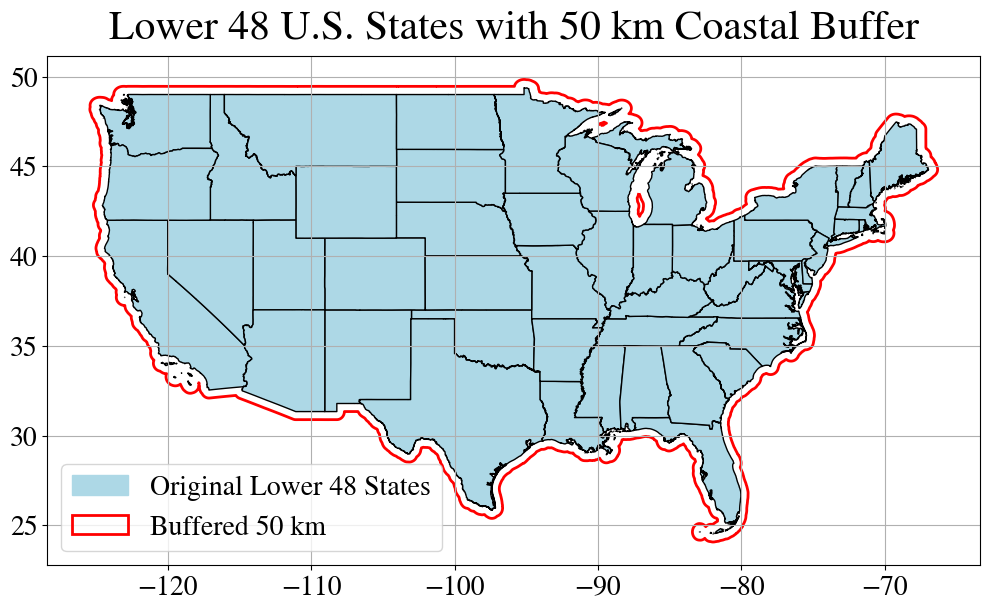

In [82]:
import matplotlib.patches as mpatches

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
gdf_lower48.plot(ax=ax, color='lightblue', edgecolor='black')
gdf_buffered.plot(ax=ax, color='none', edgecolor='red', linewidth=2)

# Create custom legend handles
original_patch = mpatches.Patch(color='lightblue', label='Original Lower 48 States')
# buffer_patch = mpatches.Patch(edgecolor='red', facecolor='none', linewidth=2, label='Buffered 100 km')
buffer_patch = mpatches.Patch(edgecolor='red', facecolor='none', linewidth=2, label='Buffered 50 km')

plt.legend(handles=[original_patch, buffer_patch], loc='lower left',fontsize=20,)
# plt.title("Lower 48 U.S. States with 100 km Coastal Buffer", fontsize=30, y=1.02)
plt.title("Lower 48 U.S. States with 50 km Coastal Buffer", fontsize=30, y=1.02)
plt.grid(True)

# Enlarge tick label font size
ax.tick_params(axis='both', which='major', labelsize=20)

# Tighten the layout
plt.tight_layout()

# Save the figure
# plt.savefig(savefig_filename, dpi=400, bbox_inches='tight')  # Adjust the filename and dpi as needed

plt.show()


# Remove ANT emissions over CONUS Box-land

In [100]:
### Read in original emissions data
CAMS_diri = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4/'

CONUSlandMasked_diri = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/'

In [90]:
# Search for files that match the pattern

import glob
import os

# Directory where files are stored
# CAMS_diri = '/path/to/your/files'  # Make sure this is correctly defined

# Updated pattern with wildcard
pattern = os.path.join(CAMS_diri, 'CAMS-GLOB-ANT_ne30np4_*_v6.2_monthly.nc')

# Get list of matching files in full path
CAMS_file_list = glob.glob(pattern)
# print(CAMS_v51_file_list)

# Extract only the filenames
CAMS_file_names = [os.path.basename(f) for f in CAMS_file_list]

print(CAMS_file_names[:3])


['CAMS-GLOB-ANT_ne30np4_C3H6_v6.2_monthly.nc', 'CAMS-GLOB-ANT_ne30np4_CH3CHO_v6.2_monthly.nc', 'CAMS-GLOB-ANT_ne30np4_C2H4_v6.2_monthly.nc']


In [91]:
spc_ls = []
for spcIdx in range(len(CAMS_file_names)):
    spc_name = CAMS_file_names[spcIdx].split('_')[4]
    spc_ls.append(spc_name)

In [92]:
import re
# Extract species name between 'ne30np4_' and '_c20210423'
species_names = [
    re.search(r'ne30np4_(.+?)_v6.2_monthly', f).group(1)
    for f in CAMS_file_names
]
species_names = sorted(species_names)
print(species_names)

['BENZENE', 'BIGALK', 'BIGENE', 'C2H2', 'C2H4', 'C2H5OH', 'C2H6', 'C3H6', 'C3H8', 'CH2O', 'CH3CHO', 'CH3CN', 'CH3COCH3', 'CH3COOH', 'CH3OH', 'CO', 'HCN', 'HCOOH', 'ISOP', 'IVOC', 'MEK', 'MTERP', 'NH3', 'NO', 'SO2', 'SVOC', 'TOLUENE', 'XYLENES', 'bc_a4', 'num_bc_a4', 'num_pom_a4', 'num_so4_a1_ag', 'num_so4_a1_ene_vertical', 'num_so4_a1_ship_fef', 'num_so4_a2_res_trs', 'pom_a4', 'so4_a1_ag_ship_fef', 'so4_a1_ene_vertical', 'so4_a2_res_trs']


In [93]:
len(species_names)

39

In [9]:
# spc_fileOUTpath = f'{CAMS_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'

In [42]:
Abs_rangeMax_dic = {'NO':7e-11,
                  'CO':5e-10,
                  'SO2':3e-11, 
                  'bc_a4':3e-12,
                  'NH3':2e-11,
                  'C2H2':2e-12, 
                  'C2H4':5e-12, # ethene
                  'C2H5OH':5e-11,
                  'C2H6':6e-12, # ethane
                  'C3H6':2e-11, 
                  'C3H8':2e-12, 
                  'CH3OH':2e-12,
                  'CH3CHO':2e-12, # 
                  'CH3COCH3':2e-12, 
                  'MEK':2e-12,
                    
                # Second panel
                  'BENZENE':3e-12, 
                  'TOLUENE':7e-12,
                  'BIGENE':4e-12,   
                  'MTERP':5e-13, 
                  'ISOP':8e-14, 
                  'CH2O':3e-12, # formaldehyde
                  'SVOC':6e-12,
                   }

## Note that the magnitude for some VOC species is much lower compared to their biogenic emissions
# MTERP: 4.90e-13 | 2.14e-13 (anthrop) compared to 
# ISOP: 8.37e-14 | 7.34e-14 (anthrop) compared to 

In [43]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'  # Change to a font that supports the superscript characters

def get_superscript(magnitude):
    return r'$10^{' + str(magnitude) + '}$'

### Create Maskds andRemove for a list of species files

In [101]:
Bufferopt = '80kmBuffer'

### Create the Masked array and save to nc file | use NO
spc = 'NO'
spc_fileINpath = f'{CAMS_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'
# Open Xarray dataset
spci_ds = xr.open_dataset(spc_fileINpath)

# MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
lat = spci_ds['lat'].values
lon = spci_ds['lon'].values
Adjustedlons = np.where(lon >= 180, lon - 360, lon)
# Create a DataArray for the adjusted lon
Adjustedlons_da = xr.DataArray(
                                Adjustedlons,  
                                dims=('ncol'),
                                coords={'ncol': spci_ds.ncol.values} 
                                )

# Add the DataArray back to the dataset
spci_ds['Adjustedlons'] = Adjustedlons_da

### To process for all months for the given period (reduce the size of processed dataset)
Timei = '2022-07-31T00:00:00.000000000'
MonthiMean_ds = spci_ds.sel(time=Timei, method="nearest")
latitudes = MonthiMean_ds.lat.values
longitudes = MonthiMean_ds.Adjustedlons.values
# MonthiMean_ds

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Create a combined mask
mask = np.zeros(len(lat), dtype=bool)

for geom in gdf_buffered['geometry']:
    for i in range(len(lat)):
        lon = Adjustedlons[i]
        lati = lat[i]
        point = Point(lon, lati)

        # Only mask if inside CONUS bounding box and also within the geometry
        in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
        if in_box and geom.contains(point):
            mask[i] = True

# Step 3: Convert to xarray mask
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False)
# sum_masked = masked_ds['sum']

### Can probably save this masked array to use later 
maskfilePath = f'/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_CONUSlandMaskedFalse_{Bufferopt}.nc'
# Save mask_da to a NetCDF file
mask_da.to_netcdf(maskfilePath)
print('Save to:', maskfilePath)

Save to: /home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_CONUSlandMaskedFalse_80kmBuffer.nc


In [102]:
Bufferopt = '80kmBuffer'
ne30maskfilePath = f'/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_CONUSlandMaskedFalse_{Bufferopt}.nc'
# Read the saved NetCDF file
mask_da_loaded = xr.open_dataarray(ne30maskfilePath)
mask_da_loaded

<xarray.DataArray (ncol: 48602)> Size: 49kB
[48602 values with dtype=bool]
Coordinates:
  * ncol     (ncol) float64 389kB 0.0 1.0 2.0 3.0 ... 4.86e+04 4.86e+04 4.86e+04

In [77]:
# masked_ds = MonthiMean_ds.where(~mask_da_loaded, drop=False)
# masked_ds

In [103]:
targetspc_ls = ['ISOP', 'NO']
timeslice_start = '2021-11-30T00:00:00.000000000'
timeslice_end = '2024-01-30T00:00:00.000000000'

for spc in targetspc_ls:
    spc_fileINpath = f'{CAMS_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'
    
    # Open Xarray dataset
    spci_ds = xr.open_dataset(spc_fileINpath)

    # MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
    lat = spci_ds['lat'].values
    lon = spci_ds['lon'].values
    Adjustedlons = np.where(lon >= 180, lon - 360, lon)
    # Create a DataArray for the adjusted lon
    Adjustedlons_da = xr.DataArray(
                                    Adjustedlons,  
                                    dims=('ncol'),
                                    coords={'ncol': spci_ds.ncol.values} 
                                    )

    # Add the DataArray back to the dataset
    spci_ds['Adjustedlons'] = Adjustedlons_da
    
    ### Use the mask read in to remove pixels over CONUS-land, need to use zero instead of nan
    sum_masked = spci_ds['sum'].where(~mask_da_loaded, other=0)

    spci_ds['sum'] = sum_masked

    # Remove the 'Adjustedlons' variable from the dataset
    spci_ds = spci_ds.drop_vars('Adjustedlons')
    
    ### Save masked to the corresponding file
    spc_fileOUTpath = f'{CONUSlandMasked_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'
    spci_ds.to_netcdf(spc_fileOUTpath)
    print('Save to:',spc_fileOUTpath)

Save to: /net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/CAMS-GLOB-ANT_ne30np4_ISOP_v6.2_monthly.nc
Save to: /net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/CAMS-GLOB-ANT_ne30np4_NO_v6.2_monthly.nc


In [50]:
masked_ds = spci_ds

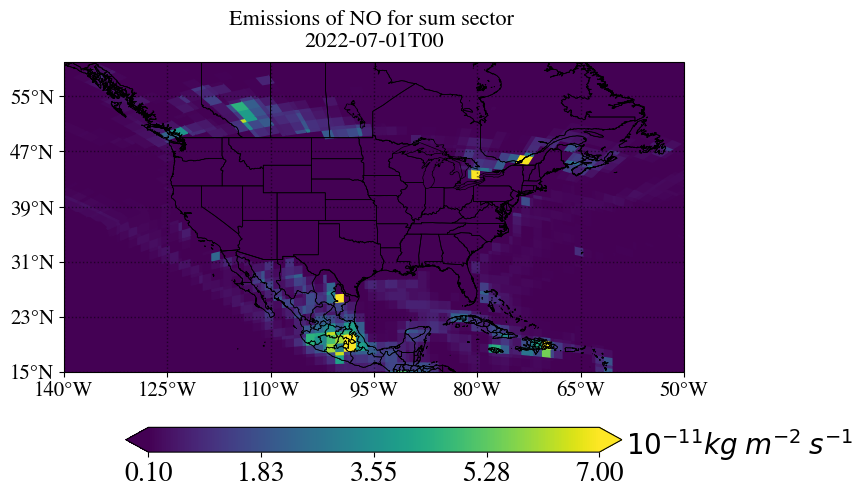

In [104]:
testfile = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/CAMS-GLOB-ANT_ne30np4_NO_v6.2_monthly.nc'
test_ds = xr.open_dataset(testfile)

### Plotting
# get rangeMax
rangeMax = Abs_rangeMax_dic[spc]

### Accounting for scientific notation
# Get the magnitude in scientific notation, adjust for e-
magnitude = int(np.floor(np.log10(abs(rangeMax))))
# Format the magnitude as a superscript
formatted_magnitude = get_superscript(str(magnitude))
modified_rangeMax = rangeMax*(1/(10)**magnitude)

# Quick plot to check
Timei = '2022-07-01T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne30)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = test_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = test_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, 
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

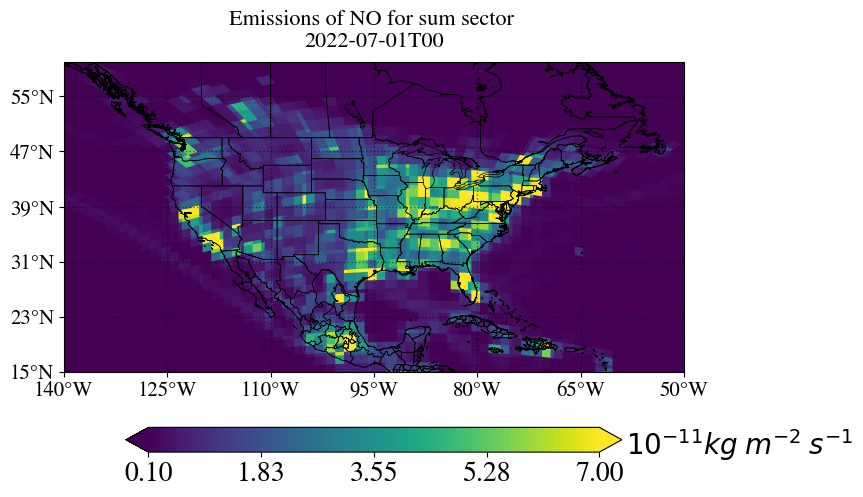

In [53]:
testfile = f'{CAMS_diri}CAMS-GLOB-ANT_ne30np4_NO_v6.2_monthly.nc'
test_ds = xr.open_dataset(testfile)

### Plotting
# get rangeMax
rangeMax = Abs_rangeMax_dic[spc]

### Accounting for scientific notation
# Get the magnitude in scientific notation, adjust for e-
magnitude = int(np.floor(np.log10(abs(rangeMax))))
# Format the magnitude as a superscript
formatted_magnitude = get_superscript(str(magnitude))
modified_rangeMax = rangeMax*(1/(10)**magnitude)

# Quick plot to check
Timei = '2022-07-01T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne30)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = test_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = masked_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, 
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [55]:
CONUSlandMasked_diri

'/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/'

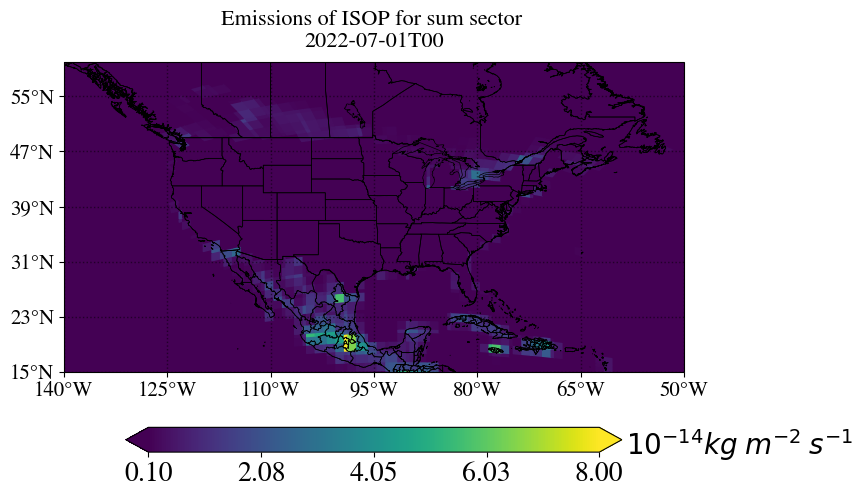

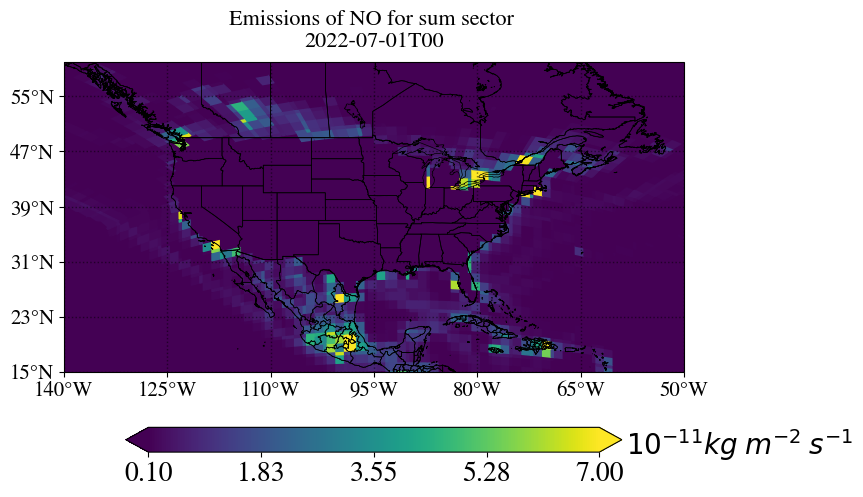

In [56]:
## Read back
for spc in targetspc_ls:
    spc_maskedINpath = f'{CONUSlandMasked_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'
    masked_ds = xr.open_dataset(spc_maskedINpath)

    ### Plotting
    # get rangeMax
    rangeMax = Abs_rangeMax_dic[spc]

    ### Accounting for scientific notation
    # Get the magnitude in scientific notation, adjust for e-
    magnitude = int(np.floor(np.log10(abs(rangeMax))))
    # Format the magnitude as a superscript
    formatted_magnitude = get_superscript(str(magnitude))
    modified_rangeMax = rangeMax*(1/(10)**magnitude)
    
    # Quick plot to check
    Timei = '2022-07-01T00:00:00.000000000'

    setmap = 'viridis'

    """ds_mappedMUSICA (regridded to ne30)"""
    PlotRegion = 'CONUS'

    # scalefactor = 1e-11
    # formatted_label = f"{scalefactor:.0e}" 

    Plot_ar = masked_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

    vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
    Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
    longname = masked_ds['sum'].long_name
    rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

    ### Which map
    fig = plt.figure( figsize=(8,6) ) 
    # - ne30x8 regional refinement over CONUS|
    ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
    if PlotRegion=="CONUS":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, lon_range=[-140,-50], lat_range=[15,60],
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
    elif PlotRegion=="Global":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, 
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

    plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [69]:
masked_ds.time.values

array(['2021-11-30T00:00:00.000000000', '2021-12-31T00:00:00.000000000',
       '2022-01-31T00:00:00.000000000', '2022-02-28T00:00:00.000000000',
       '2022-03-31T00:00:00.000000000', '2022-04-30T00:00:00.000000000',
       '2022-05-31T00:00:00.000000000', '2022-06-30T00:00:00.000000000',
       '2022-07-31T00:00:00.000000000', '2022-08-31T00:00:00.000000000',
       '2022-09-30T00:00:00.000000000', '2022-10-31T00:00:00.000000000',
       '2022-11-30T00:00:00.000000000'], dtype='datetime64[ns]')

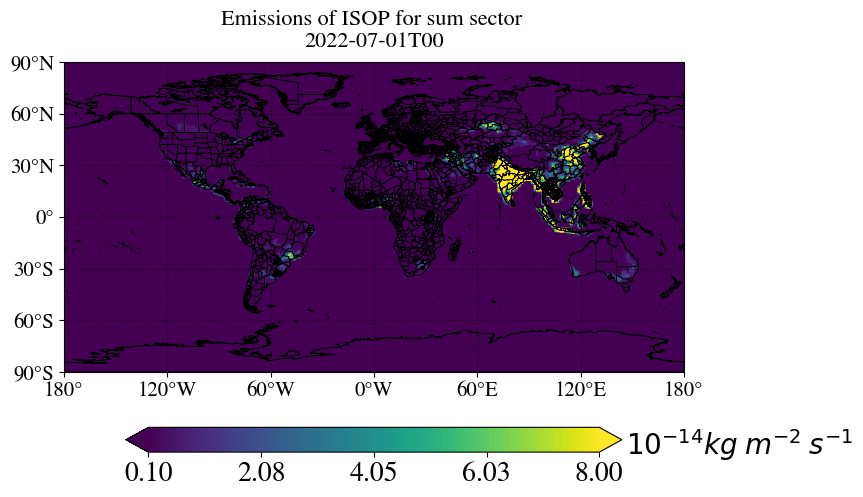

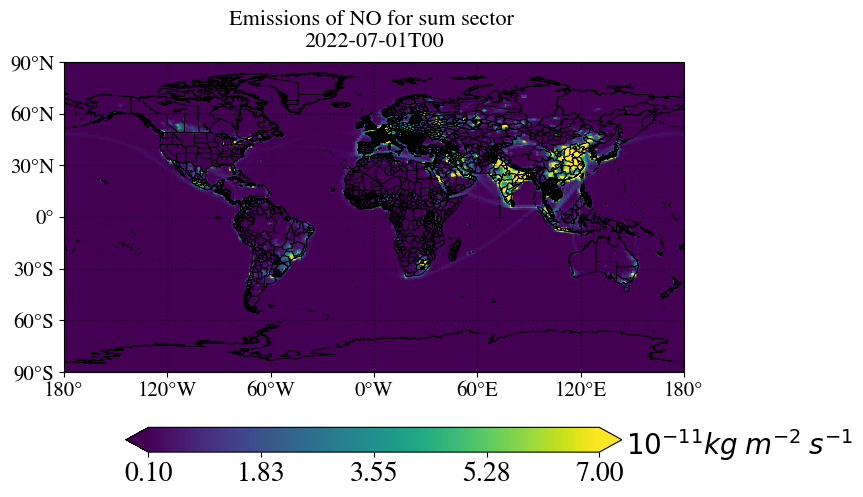

In [57]:
## Read back
for spc in targetspc_ls:
    spc_maskedINpath = f'{CONUSlandMasked_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'
    masked_ds = xr.open_dataset(spc_maskedINpath)

    ### Plotting
    # get rangeMax
    rangeMax = Abs_rangeMax_dic[spc]

    ### Accounting for scientific notation
    # Get the magnitude in scientific notation, adjust for e-
    magnitude = int(np.floor(np.log10(abs(rangeMax))))
    # Format the magnitude as a superscript
    formatted_magnitude = get_superscript(str(magnitude))
    modified_rangeMax = rangeMax*(1/(10)**magnitude)
    
    # Quick plot to check
    Timei = '2022-07-01T00:00:00.000000000'

    setmap = 'viridis'

    """ds_mappedMUSICA (regridded to ne30)"""
    PlotRegion = 'Global'

    # scalefactor = 1e-11
    # formatted_label = f"{scalefactor:.0e}" 

    Plot_ar = masked_ds.sel(time=Timei,method='nearest')['sum'].values#*scalefactor

    vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
    Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
    longname = masked_ds['sum'].long_name
    rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

    ### Which map
    fig = plt.figure( figsize=(8,6) ) 
    # - ne30x8 regional refinement over CONUS|
    ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
    if PlotRegion=="CONUS":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, lon_range=[-140,-50], lat_range=[15,60],
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
    elif PlotRegion=="Global":
        im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
                cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
                unit=f'{formatted_magnitude}{Plot_unit}',
                state=True, 
                  grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

    plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

##### Test for Nitric Oxide Emissions (NO) | 2-D and only contains 'sum' sector

In [41]:
spc = 'NO'
spc_fileINpath = f'{CAMS_diri}CAMS-GLOB-ANT_v5.1_2000-2021_ne30np4_{spc}_c20210423_modified.nc'

# get rangeMax
rangeMax = Abs_rangeMax_dic[spc]

### Accounting for scientific notation
# Get the magnitude in scientific notation, adjust for e-
magnitude = int(np.floor(np.log10(abs(rangeMax))))
# Format the magnitude as a superscript
formatted_magnitude = get_superscript(str(magnitude))
modified_rangeMax = rangeMax*(1/(10)**magnitude)

In [42]:
# Open Xarray dataset
spci_ds = xr.open_dataset(spc_fileINpath)

# MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
lat = spci_ds['lat'].values
lon = spci_ds['lon'].values
Adjustedlons = np.where(lon >= 180, lon - 360, lon)
# Create a DataArray for the adjusted lon
Adjustedlons_da = xr.DataArray(
                                Adjustedlons,  
                                dims=('ncol'),
                                coords={'ncol': spci_ds.ncol.values} 
                                )

# Add the DataArray back to the dataset
spci_ds['Adjustedlons'] = Adjustedlons_da

In [27]:
spci_ds

<xarray.Dataset> Size: 53MB
Dimensions:       (time: 264, ncol: 48602)
Coordinates:
  * time          (time) datetime64[ns] 2kB 2000-12-31 2001-01-31 ... 2022-11-30
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (time) int32 1kB ...
    month_day     (time) int32 1kB ...
    date          (time) int32 1kB ...
    area          (ncol) float64 389kB ...
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (time, ncol) float32 51MB ...
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


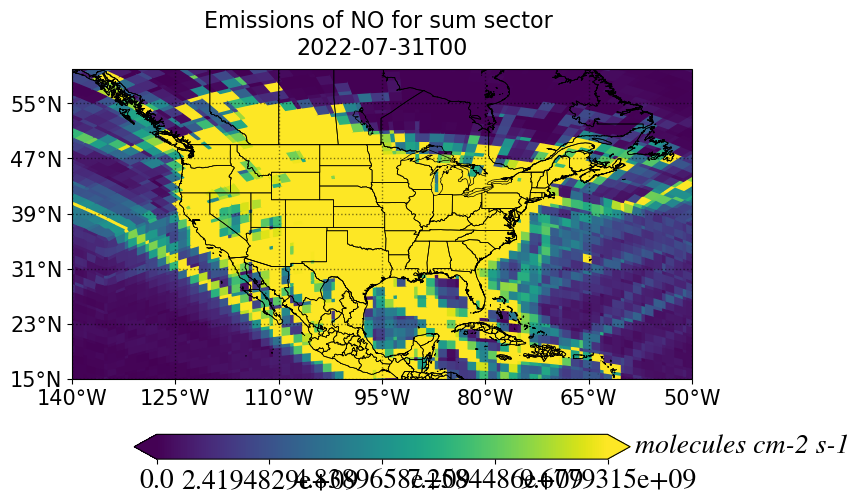

In [11]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


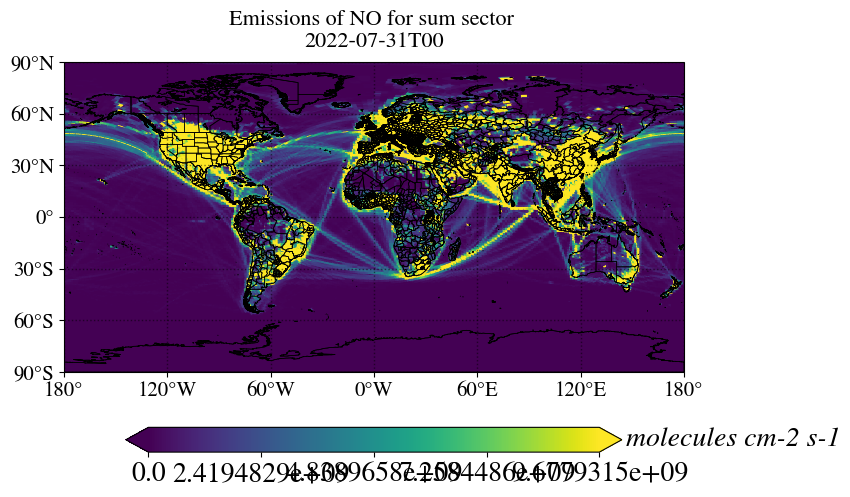

In [12]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 
MonthiMean_da = spci_ds.sel(time=Timei)['sum']

Plot_ar = spci_ds.sel(time=Timei)['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [ ]:
spci_ds.time.values

In [27]:
# timeslice_start = '2021-11-30T00:00:00.000000000'
# timeslice_end = '2022-11-30T00:00:00.000000000'


# seltimeMean_ds = spci_ds.sel(time=slice(timeslice_start,timeslice_end))
# latitudes = seltimeMean_ds.lat.values
# longitudes = seltimeMean_ds.Adjustedlons.values
# # seltimeMean_ds

# # Step 1: Define CONUS bounding box
# lon_lefti = -66.95   # Eastern edge
# lon_righti = -125.0  # Western edge
# lat_boti = 24.4      # Southern edge
# lat_upi = 49.5       # Northern edge

# # Step 2: Create a combined mask
# mask = np.zeros(len(lat), dtype=bool)

# for geom in gdf['geometry']:
#     for i in range(len(lat)):
#         lon = Adjustedlons[i]
#         lati = lat[i]
#         point = Point(lon, lati)

#         # Only mask if inside CONUS bounding box and also within the geometry
#         in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
#         if in_box and geom.contains(point):
#             mask[i] = True

# # Step 3: Convert to xarray mask
# mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# # Step 4: Apply the mask to remove CONUS land pixels
# masked_ds = seltimeMean_ds.where(~mask_da, drop=False)
# sum_masked = masked_ds['sum']


In [55]:
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import xarray as xr

# Define the time slice
timeslice_start = '2021-11-30T00:00:00.000000000'
timeslice_end = '2022-11-30T00:00:00.000000000'
seltimeMean_ds = spci_ds.sel(time=slice(timeslice_start, timeslice_end))

# Extract coordinates
lat = seltimeMean_ds['lat'].values
lon = seltimeMean_ds['Adjustedlons'].values

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Use the buffered shape to mask
from shapely.geometry import Point

mask = np.zeros(len(lat), dtype=bool)
geom = gdf_buffered.iloc[0].geometry  # The buffered CONUS geometry

for i in range(len(lat)):
    point = Point(lon[i], lat[i])
    in_box = (lon[i] >= lon_righti) & (lon[i] <= lon_lefti) & (lat[i] >= lat_boti) & (lat[i] <= lat_upi)
    if in_box and geom.contains(point):
        mask[i] = True

# Step 3: Convert mask to DataArray
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": seltimeMean_ds["ncol"]})

# Step 4: Apply the mask (keep values outside the CONUS buffered shape)
masked_ds = seltimeMean_ds.where(~mask_da, drop=False)

# Extract masked variable (optional)
sum_masked = masked_ds['sum']


In [56]:
### Can probably save this masked array to use later 
savefilePath = '/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_Lower48StatesCoastal50kmMaskedFalse.nc'
# Save mask_da to a NetCDF file
mask_da.to_netcdf(savefilePath)

In [57]:
mask_da

<xarray.DataArray (ncol: 48602)> Size: 49kB
array([False, False, False, ..., False, False, False])
Coordinates:
  * ncol     (ncol) float64 389kB 0.0 1.0 2.0 3.0 ... 4.86e+04 4.86e+04 4.86e+04

In [46]:
masked_ds = seltimeMean_ds.where(~mask_da, drop=False)
masked_ds

<xarray.Dataset> Size: 20MB
Dimensions:       (time: 13, ncol: 48602)
Coordinates:
  * time          (time) datetime64[ns] 104B 2021-11-30 ... 2022-11-30
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (time, ncol) float64 5MB 2.02e+03 2.02e+03 ... 2.021e+03
    month_day     (time, ncol) float64 5MB 1.115e+03 1.115e+03 ... 1.115e+03
    date          (time, ncol) float64 5MB 2.021e+07 2.021e+07 ... 2.022e+07
    area          (ncol) float64 389kB 4.397e-05 0.0001465 ... 0.0003665
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (time, ncol) float32 3MB 1.089e+09 3.526e+08 ... 7.067e+09
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

In [58]:
### To process for all months for the given period (reduce the size of processed dataset)
Timei = '2022-07-31T00:00:00.000000000'

seltimeMean_ds = spci_ds.sel(time=Timei)
latitudes = seltimeMean_ds.lat.values
longitudes = seltimeMean_ds.Adjustedlons.values
# MonthiMean_ds

# Extract coordinates
lat = seltimeMean_ds['lat'].values
lon = seltimeMean_ds['Adjustedlons'].values

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Use the buffered shape to mask
from shapely.geometry import Point

mask = np.zeros(len(lat), dtype=bool)
geom = gdf_buffered.iloc[0].geometry  # The buffered CONUS geometry

for i in range(len(lat)):
    point = Point(lon[i], lat[i])
    in_box = (lon[i] >= lon_righti) & (lon[i] <= lon_lefti) & (lat[i] >= lat_boti) & (lat[i] <= lat_upi)
    if in_box and geom.contains(point):
        mask[i] = True

# Step 3: Convert mask to DataArray
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": seltimeMean_ds["ncol"]})

# Step 4: Apply the mask (keep values outside the CONUS buffered shape)
masked_ds = seltimeMean_ds.where(~mask_da, drop=False)

# Extract masked variable (optional)
sum_masked = masked_ds['sum']


In [49]:
sum_masked

<xarray.DataArray 'sum' (ncol: 48602)> Size: 194kB
array([8.4442291e+08, 1.7281021e+08, 9.2917936e+07, ..., 1.0683996e+10,
       6.6580517e+10, 8.8879596e+09], dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2022-07-31
  * ncol     (ncol) float64 389kB 0.0 1.0 2.0 3.0 ... 4.86e+04 4.86e+04 4.86e+04
Attributes:
    standard_name:           NO
    long_name:               Emissions of NO for sum sector
    units:                   molecules cm-2 s-1
    molecular_weight:        30.0
    molecular_weight_units:  g mole-1
    sector_name:             Agriculture soils

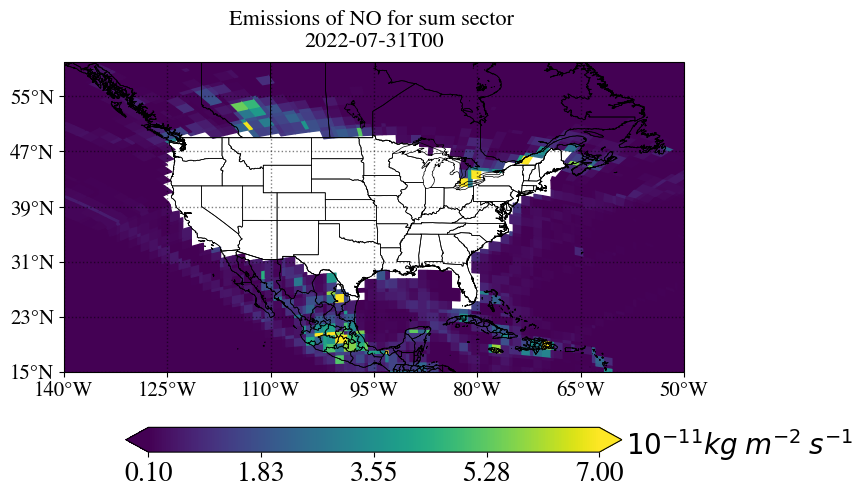

In [59]:
# Quick plot to check

setmap =  'viridis' #'CMRmap_r'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = spci_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            # state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

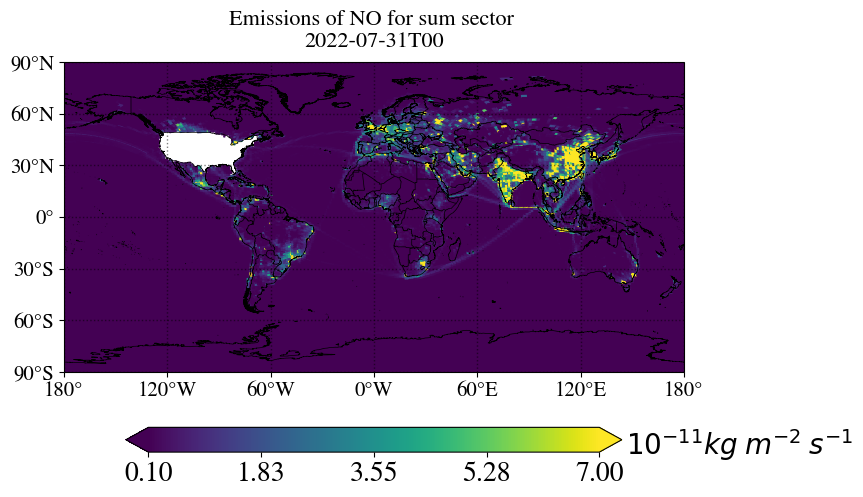

In [60]:
# Quick plot to check

setmap = 'viridis' #'CMRmap_r'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
vari_kg_per_m2_per_s = molecules_to_kg_per_m2_per_s(Plot_ar, spci_ds['sum'].molecular_weight)
Plot_unit = r'$kg$ $m^{-2}$ $s^{-1}$'
longname = spci_ds['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True ) 
elif PlotRegion=="Global":
    im = Plot_2D( vari_kg_per_m2_per_s*(1/(10)**magnitude), scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0.1, cmax=modified_rangeMax, cmap=setmap, 
            unit=f'{formatted_magnitude}{Plot_unit}',
            # state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15, twodecimal=True )   

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

##### Trial

In [26]:
MonthiMean_ds = spci_ds.sel(time=Timei)
latitudes = MonthiMean_ds.lat.values
longitudes = MonthiMean_ds.Adjustedlons.values
MonthiMean_ds

<xarray.Dataset> Size: 2MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          int32 4B ...
    month_day     int32 4B ...
    date          int32 4B ...
    area          (ncol) float64 389kB ...
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB ...
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

In [ ]:
### First select over land
import rasterio
from rasterio.features import rasterize
# **Load High-Resolution Land Shapefile**
land_shapefile = "/home/taoma528/HelpfulFiles/ne_10m_land/ne_10m_land.shp"
gdf_land = gpd.read_file(land_shapefile)

# select for land pixel only
# **Define Raster Transform (Corrected)**
transform = rasterio.transform.from_bounds(
    longitudes.min(), latitudes.max(),  # Bottom-left corner
    longitudes.max(), latitudes.min(),  # Top-right corner
    len(longitudes), len(latitudes)     # Grid size
)

# **Rasterize Land Mask (1=Land, 0=Water)**
land_mask = rasterize(
    [(geom, 1) for geom in gdf_land.geometry], 
    out_shape=(len(latitudes), len(longitudes)), 
    transform=transform, 
    fill=0, 
    all_touched=True,  # Ensures land edges are included
    dtype=np.uint8
)

land_mask_xr = xr.DataArray(
    land_mask, 
    dims=["lat", "Adjustedlons"], 
    coords={"lat": MonthiMean_ds["lat"], "Adjustedlons": MonthiMean_ds["Adjustedlons"]}
)

# **Apply Mask to Dataset**
MonthiMean_da_land = MonthiMean_da.where(land_mask_xr)

In [40]:
gdf_land

,featurecla,scalerank,min_zoom,geometry
0,Land,0.0,0.0,"MULTIPOLYGON (((-0.00029 -71.49903, 0.01555 -7..."
1,Land,6.0,5.0,"MULTIPOLYGON (((166.13697 -50.86435, 166.20525..."
2,Land,5.0,3.0,"MULTIPOLYGON (((-78.78897 -33.60906, -78.78038..."
3,Land,6.0,6.0,"MULTIPOLYGON (((163.98512 -20.04762, 163.98609..."
4,Land,5.0,4.0,"MULTIPOLYGON (((134.70737 -6.58904, 134.72006 ..."
5,Land,3.0,2.0,"MULTIPOLYGON (((-80.05989 -2.66277, -80.01452 ..."
6,Land,0.0,1.0,"MULTIPOLYGON (((81.87599 7.09195, 81.87843 7.0..."
7,None,NaN,NaN,"MULTIPOLYGON (((55.018 24.97651, 55.0158 24.97..."
8,Land,1.0,1.5,"MULTIPOLYGON (((134.68979 33.82807, 134.72203 ..."
9,Land,5.0,0.5,"MULTIPOLYGON (((14.76303 68.49486, 14.71746 68..."


In [36]:
### Mask values within the CONUS box (rectangular lat-lon box)
fileregion = 'CONUS_refined'

# Refined lat-lon bounding box for CONUS
lon_lefti = -66.95   # Eastern edge (near Maine)
lon_righti = -125.0  # Western edge (near California)
lat_boti = 24.4      # Southern edge (near southern Florida)
lat_upi = 49.5       # Northern edge (U.S.–Canada border)


# Define the mask for the bounding box
mask_inside = (
    (MonthiMean_ds['Adjustedlons'] >= lon_righti) &
    (MonthiMean_ds['Adjustedlons'] <= lon_lefti) &
    (MonthiMean_ds['lat'] >= lat_boti) &
    (MonthiMean_ds['lat'] <= lat_upi)
)

# Invert the mask to get data OUTSIDE the box
mask_outside = ~mask_inside

# Apply the mask to get data outside the region
outside_region_VCDds = MonthiMean_ds.where(mask_outside)


In [37]:
outside_region_VCDds

<xarray.Dataset> Size: 3MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (ncol) float64 389kB 2.021e+03 2.021e+03 ... 2.021e+03
    month_day     (ncol) float64 389kB 715.0 715.0 715.0 ... 715.0 715.0 715.0
    date          (ncol) float64 389kB 2.022e+07 2.022e+07 ... 2.022e+07
    area          (ncol) float64 389kB 4.397e-05 0.0001465 ... 0.0003665
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB 8.444e+08 1.728e+08 ... 8.888e+09
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


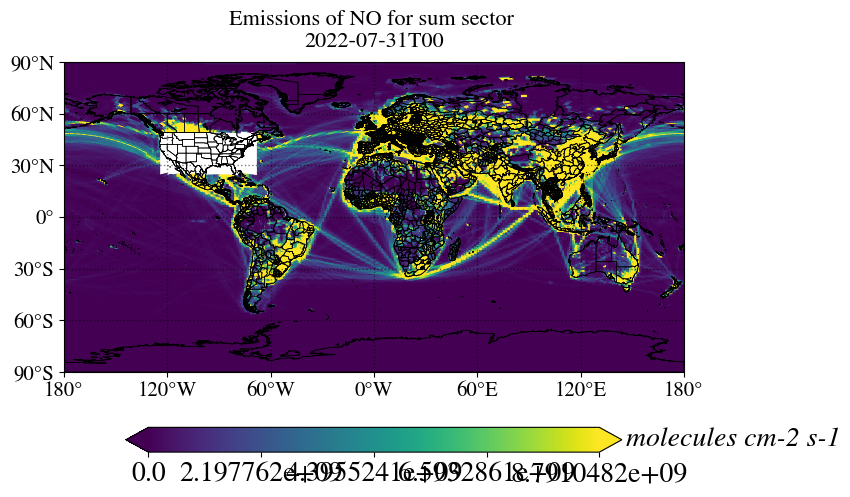

In [38]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = outside_region_VCDds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


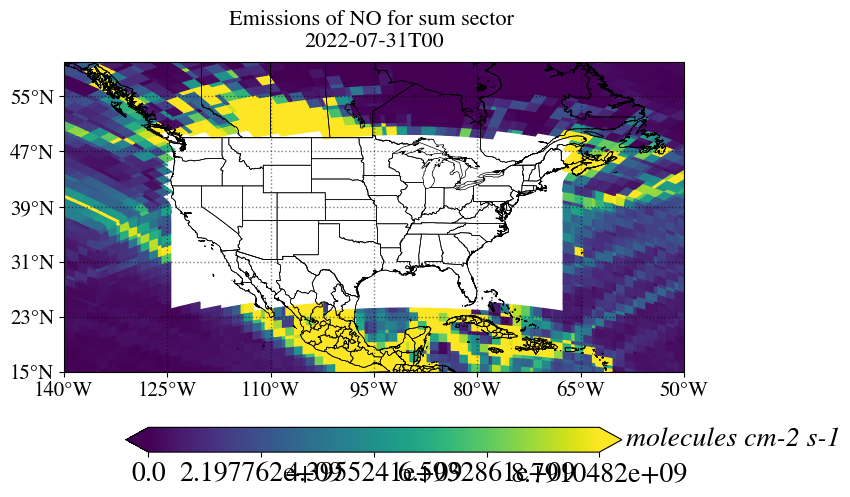

In [39]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = outside_region_VCDds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

In [ ]:
### To remove only land pixels over the CONUS (keep everythingelse)
# Remove if NOT over water & within the CONUS box 

# Step 1: Pixels outside the CONUS box
mask_outside = ~mask_inside

# Step 2: Pixels inside CONUS box but over water
mask_inside_water = mask_inside & (~land_mask)

# Step 3: Combine the two
final_mask = mask_outside | mask_inside_water

# Step 4: Apply the mask
outside_water_or_outsideCONUS_ds = MonthiMean_ds.where(final_mask)


In [41]:
import geopandas as gpd

# Path to the shapefile (adjust if the file is inside a folder)
shapefile_path = '/home/taoma528/HelpfulFiles/world-administrative-boundaries/world-administrative-boundaries.shp'

# Read shapefile directly
gdf = gpd.read_file(shapefile_path)

# Preview
print(gdf.columns)
print(gdf.head())


Index(['iso3', 'status', 'color_code', 'name', 'continent', 'region',
       'iso_3166_1_', 'french_shor', 'geometry'],
      dtype='object')
   iso3                 status color_code                      name continent  \
0   MNP           US Territory        USA  Northern Mariana Islands   Oceania   
1  None  Sovereignty unsettled        RUS             Kuril Islands      Asia   
2   FRA           Member State        FRA                    France    Europe   
3   SRB           Member State        SRB                    Serbia    Europe   
4   URY           Member State        URY                   Uruguay  Americas   

            region iso_3166_1_               french_shor  \
0       Micronesia          MP  Northern Mariana Islands   
1     Eastern Asia        None             Kuril Islands   
2   Western Europe          FR                    France   
3  Southern Europe          RS                    Serbie   
4    South America          UY                   Uruguay   

          

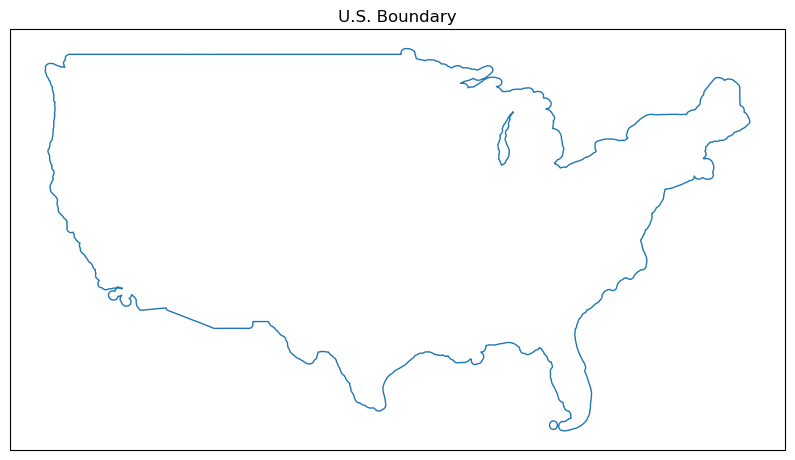

In [29]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
# gdf.plot(ax=ax, color='tab:blue', edgecolor='black')
gdf_buffered.plot(ax=ax, color='white', edgecolor='tab:blue')

# # Set the extent to the bounding box coordinates
# ax.set_extent([-74.5, -73.5, 40.4, 41], crs=ccrs.PlateCarree())

# Customize the plot (optional)
ax.set_title('U.S. Boundary')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Show the plot
plt.show()

In [68]:
# # Create a mask for the dataset
# mask = np.zeros(len(lat), dtype=bool)

# # Iterate over the geometries and update the mask
# points_within_bounds = []
# for geom in gdf['geometry']:
#     for i in range(len(lat)):
#         point = Point(Adjustedlons[i], lat[i])
#         if geom.contains(point):
#             points_within_bounds.append((Adjustedlons[i], lat[i]))
#             mask[i] = True

# # Convert mask to DataArray
# mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# # Apply the mask to the dataset
# masked_ds = MonthiMean_ds.where(mask_da, drop=True)

# # Apply the mask to the 'sum' variable
# # sum_masked = spci_ds['sum'].where(~mask_da, other=np.nan)
# sum_masked = spci_ds['sum'].where(~mask_da, other=0)

In [69]:
from shapely.geometry import Point
import numpy as np
import xarray as xr

# Step 1: Define CONUS bounding box
lon_lefti = -66.95   # Eastern edge
lon_righti = -125.0  # Western edge
lat_boti = 24.4      # Southern edge
lat_upi = 49.5       # Northern edge

# Step 2: Create a combined mask
mask = np.zeros(len(lat), dtype=bool)

for geom in gdf['geometry']:
    for i in range(len(lat)):
        lon = Adjustedlons[i]
        lati = lat[i]
        point = Point(lon, lati)

        # Only mask if inside CONUS bounding box and also within the geometry
        in_box = (lon >= lon_righti) & (lon <= lon_lefti) & (lati >= lat_boti) & (lati <= lat_upi)
        if in_box and geom.contains(point):
            mask[i] = True

# Step 3: Convert to xarray mask
mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False) # do not drop to keep the same size

# Optionally apply it to just one variable
sum_masked = masked_ds['sum']


In [74]:
# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False)
sum_masked = masked_ds['sum']

In [73]:
MonthiMean_ds

<xarray.Dataset> Size: 2MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          int32 4B ...
    month_day     int32 4B ...
    date          int32 4B ...
    area          (ncol) float64 389kB ...
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB ...
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

In [75]:
masked_ds

<xarray.Dataset> Size: 3MB
Dimensions:       (ncol: 48602)
Coordinates:
    time          datetime64[ns] 8B 2022-07-31
  * ncol          (ncol) float64 389kB 0.0 1.0 2.0 ... 4.86e+04 4.86e+04
Data variables:
    year          (ncol) float64 389kB 2.021e+03 2.021e+03 ... 2.021e+03
    month_day     (ncol) float64 389kB 715.0 715.0 715.0 ... 715.0 715.0 715.0
    date          (ncol) float64 389kB 2.022e+07 2.022e+07 ... 2.022e+07
    area          (ncol) float64 389kB 4.397e-05 0.0001465 ... 0.0003665
    lat           (ncol) float64 389kB -35.26 -35.65 -36.26 ... 36.68 36.05
    lon           (ncol) float64 389kB 315.0 315.8 317.2 ... 133.7 136.3 135.0
    sum           (ncol) float32 194kB 8.444e+08 1.728e+08 ... 8.888e+09
    Adjustedlons  (ncol) float64 389kB -45.0 -44.17 -42.83 ... 133.7 136.3 135.0
Attributes: (12/29)
    distribution_date:                    2021-01-27
    creation_date:                        2021-03-12 11:08:05 UTC
    Conventions:                          CF-1.6
    projection:                           latlon
    authors:                              N.Elguindi and C.Granier
    product_version:                      v4.2-S1.1
    ...                                   ...
    remmaped_from_files:                  from file(s): /glade/p/nsc/nacd0023...
    mapping_equation:                     NO[30]       = 1.0*nox             ...
    remapped_by:                          Species_Mapping.py tool
    remapping_time:                       2021-04-23 14:09:16.044521
    remmaping_username:                   cdswk on crhtc36.hpc.ucar.edu
    comment_from_Species_Mapping_script:  day of each month of date array was...

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


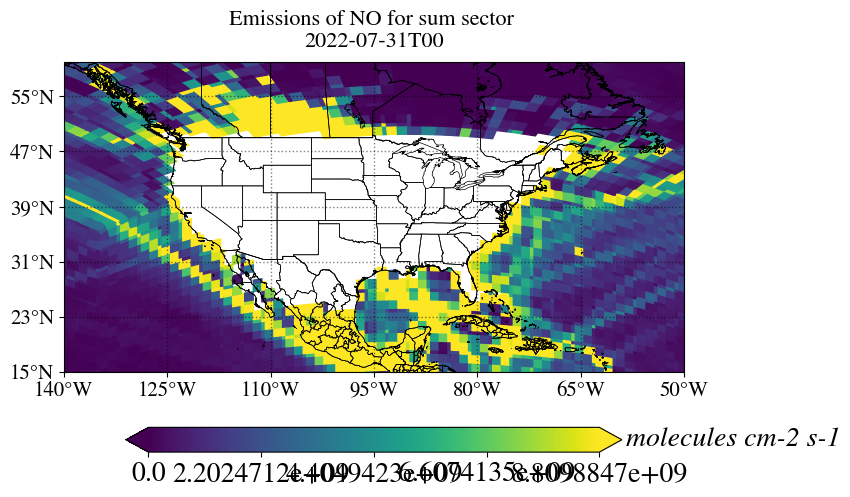

In [77]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'CONUS'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

/home/taoma528/Scripts/CESM_analysis/functions/Plot_2D.py:897: RuntimeWarning: invalid value encountered in cast
  checksum = np.sum( np.abs( tmparray - tmparray.astype('i') ) )


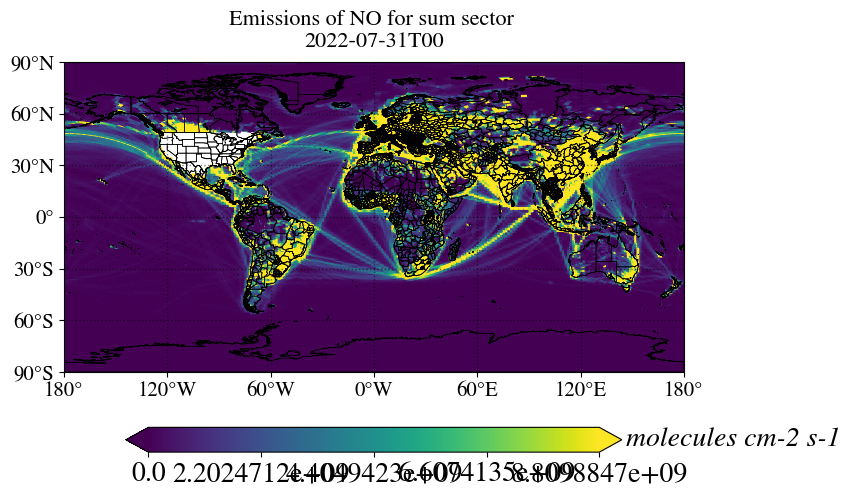

In [79]:
# Quick plot to check

Timei = '2022-07-31T00:00:00.000000000'

setmap = 'viridis'

"""ds_mappedMUSICA (regridded to ne0CONUS30x8)"""
PlotRegion = 'Global'

# scalefactor = 1e-11
# formatted_label = f"{scalefactor:.0e}" 

Plot_ar = masked_ds['sum'].values#*scalefactor
Plot_unit = spci_ds.sel(time=Timei)['sum'].units#+' ('+formatted_label+')'
longname = spci_ds.sel(time=Timei)['sum'].long_name
rangeMax = np.nanmean(Plot_ar) #setvmax*scalefactor

### Which map
fig = plt.figure( figsize=(8,6) ) 
# - ne30x8 regional refinement over CONUS|
ax1 = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())
if PlotRegion=="CONUS":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-140,-50], lat_range=[15,60],
              grid_line=False, grid_line_lw=0.15 ) 
elif PlotRegion=="Global":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True,grid_line=False, grid_line_lw=0.15 )  
elif PlotRegion=="NYC":
    im = Plot_2D( Plot_ar, scrip_file=SCRIP_ne30, ax=ax1,
            cmin=0, cmax=rangeMax, cmap=setmap, 
            unit=Plot_unit,
            state=True, lon_range=[-74.5,-73.5], lat_range=[40.4,41],
              grid_line=False, grid_line_lw=0.15 ) 

plt.title(longname+' \n'+Timei[:13], fontsize=16, y=1.02);

## Process for all target files

In [ ]:
Bufferopt = '80kmBuffer'
ne30maskfilePath = f'/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons_CONUSlandMaskedFalse_{Bufferopt}.nc'
# Read the saved NetCDF file
mask_da_loaded = xr.open_dataarray(ne30maskfilePath)
mask_da_loaded

In [ ]:
targetspc_ls = species_names
timeslice_start = '2021-11-30T00:00:00.000000000'
timeslice_end = '2024-01-30T00:00:00.000000000'

for spc in targetspc_ls:
    spc_fileINpath = f'{CAMS_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'
    
    # Open Xarray dataset
    spci_ds = xr.open_dataset(spc_fileINpath)

    # MUSICA lons goes from 0-360, convert it to +-180 | Need to adjust lon_right and lon_left for MUSICA!!
    lat = spci_ds['lat'].values
    lon = spci_ds['lon'].values
    Adjustedlons = np.where(lon >= 180, lon - 360, lon)
    # Create a DataArray for the adjusted lon
    Adjustedlons_da = xr.DataArray(
                                    Adjustedlons,  
                                    dims=('ncol'),
                                    coords={'ncol': spci_ds.ncol.values} 
                                    )

    # Add the DataArray back to the dataset
    spci_ds['Adjustedlons'] = Adjustedlons_da
    
    ### Use the mask read in to remove pixels over CONUS-land, need to use zero instead of nan
    sum_masked = spci_ds['sum'].where(~mask_da_loaded, other=0)

    spci_ds['sum'] = sum_masked

    # Remove the 'Adjustedlons' variable from the dataset
    spci_ds = spci_ds.drop_vars('Adjustedlons')
    
    ### Save masked to the corresponding file
    spc_fileOUTpath = f'{CONUSlandMasked_diri}CAMS-GLOB-ANT_ne30np4_{spc}_v6.2_monthly.nc'
    spci_ds.to_netcdf(spc_fileOUTpath)
    print('Save to:',spc_fileOUTpath)
    print( '************************************************************************' )

# Estimate CONUS Emissions (numbers replaced with zero)

In [ ]:
"""Need to change"""
### Estimate emissions within NYC boundary

import os
import numpy as np
import xarray as xr
from shapely.geometry import Point

# Define dictionary to store emission sums set to zero
city_emissions = {}

# Read in each file in the format 
# for spc in updated_spcs[:2]:
for spc in updated_spcs:
    # Construct file path
    FileInPath = f'{hourlyNEI_diri}NEI2017Merged_20181MJuly_CAMSv5.1_anthro_2018_ne0CONUSne30x8_{spc}_c20231113.nc'
    
    # Check if the file exists
    if not os.path.exists(FileInPath):
        print(f"{FileInPath} missing.")
        continue

    print(f'Calculating NYC-summed July mean emissions for {spc}')
    print('************************************************************************')

    # Open the dataset
    spci_ds = xr.open_dataset(FileInPath)

    # Adjust longitudes from 0-360 to -180 to 180
    lat = spci_ds['lat'].values
    lon = spci_ds['lon'].values
    Adjustedlons = np.where(lon >= 180, lon - 360, lon)
    Adjustedlons_da = xr.DataArray(Adjustedlons, dims=('ncol'), coords={'ncol': spci_ds.ncol.values})
    spci_ds['Adjustedlons'] = Adjustedlons_da

    # Create a mask based on the boundary geometry
    mask = np.zeros(len(lat), dtype=bool)
    for geom in gdf['geometry']:
        for i in range(len(lat)):
            point = Point(Adjustedlons[i], lat[i])
            if geom.contains(point):
                mask[i] = True

    mask_da = xr.DataArray(mask, dims=["ncol"], coords={"ncol": spci_ds["ncol"]})

    # Initialize dictionary for this city and species if not already created
    if spc not in city_emissions:
        city_emissions[spc] = {}

    # Iterate over variables except those to ignore, apply mask, set to 0, and calculate sum
    excluded_vars = ['lon', 'lat', 'area', 'rrfac', 'date', 'Adjustedlons']
    for var_name in spci_ds.data_vars:
        if var_name not in excluded_vars:
            print(var_name)
            # Set emissions to zero within the boundary
            zeroed_emissions = spci_ds[var_name].where(~mask_da, other=0)
            
            # Calculate sum of emissions that were set to zero
            sum_Cityi_emissions = spci_ds[var_name].where(mask_da).sum().item() # use .item() to get just the number

            # Store the result in the dictionary
            if var_name not in city_emissions[spc]:
                city_emissions[spc][var_name] = sum_Cityi_emissions
                # add unit information
                city_emissions[spc]["unites"] = spci_ds["sum"].units

    print('************************************************************************')



Calculating NYC-summed July mean emissions for CH3OH
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for num_pom_a4
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for NH3
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for BIGENE
************************************************************************
sum
************************************************************************
Calculating NYC-summed July mean emissions for TOLUENE
************************************************************************
sum
****************************************************

In [10]:
# Flatten the dictionary to create a DataFrame with separate columns for sum and units
flattened_data = {
    species: {'sum': details['sum'], 'units': details['unites']}
    for species, details in city_emissions.items()
}

# Convert to DataFrame
emissions_df = pd.DataFrame(flattened_data).T

# Format the 'sum' column in scientific notation with 2 decimal places
emissions_df['sum'] = emissions_df['sum'].apply(lambda x: f"{x:.2e}")

emissions_df

,sum,units
CH3OH,2.05e+14,molecules cm-2 s-1
num_pom_a4,3.21e+33,(particles cm-2 s-1)(molecules mole-1)(g kg-1)
NH3,4.05e+14,molecules cm-2 s-1
BIGENE,1.49e+14,molecules cm-2 s-1
TOLUENE,2.57e+14,molecules cm-2 s-1
C3H8,1.78e+14,molecules cm-2 s-1
pom_a4,2.49e+15,molecules cm-2 s-1
bc_a4,4.53e+14,molecules cm-2 s-1
ISOP,2.20e+12,molecules cm-2 s-1
BENZENE,4.74e+13,molecules cm-2 s-1


In [11]:
# Export the DataFrame to CSV
csv_path = "./NYCsummed_JulyMean_AnthroEmis.csv"
emissions_df.to_csv(csv_path)

print("Saved to:", csv_path)

Saved to: ./NYCsummed_JulyMean_AnthroEmis.csv


#### Draft checking calculations

In [33]:
city_emissions

{'CH3OH': {'sum': 204575634096128.0},
 'num_pom_a4': {'sum': 3.2058617522663475e+33}}

In [25]:
zeroed_emissions.sum()

<xarray.DataArray 'sum' ()>
array(4.996124e+16, dtype=float32)

In [21]:
var_name = 'sum'

In [27]:
spci_ds[var_name].sum().item()

5.016578924793037e+16

In [22]:
spci_ds[var_name].where(mask_da).sum()

<xarray.DataArray 'sum' ()>
array(2.0457563e+14, dtype=float32)

In [26]:
zeroed_emissions.sum()+spci_ds[var_name].where(mask_da).sum()

<xarray.DataArray 'sum' ()>
array(5.0165815e+16, dtype=float32)

In [ ]:
['lon','lat','area','rrfac','date','Adjustedlons']

# Analyze Output Simulations

# Remove CMIP6-Aircraft emissions over CONUS Box-land

In [105]:
# ### Locate aircraft emissions fires
# aircraft_emisfilepaths = [
# '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approxY2022Y2023/emissions-cmip6_SO2_aircraft_verticto2025use2011to2015_.9x1.25_c20170608.nc',
# '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approxY2022Y2023/emissions-cmip6_num_bc_a4_aircraft_verticto2025use2011to2015_.9x1.25_c20170608.nc',
# '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approxY2022Y2023/emissions-cmip6_bc_a4_aircraft_verticto2025use2011to2015_.9x1.25_c20170608.nc',
# '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approxY2022Y2023/emissions-cmip6_NO2_aircraft_verticto2025use2011to2015_.9x1.25_c20170608.nc',
# ]

In [110]:
### Locate aircraft emissions fires
aircraft_emisfilepaths = [
'/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approx2022/emissions-cmip6_SO2_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
'/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approx2022/emissions-cmip6_num_bc_a4_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
'/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approx2022/emissions-cmip6_bc_a4_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
'/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approx2022/emissions-cmip6_NO2_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
]

In [117]:
# Read one file in to create a mask for f09 (.9x1.25) resolution
spc_fileINpath = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approx2022/emissions-cmip6_NO2_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc'
# Open Xarray dataset
spci_ds = xr.open_dataset(spc_fileINpath)
spci_ds

<xarray.Dataset> Size: 77MB
Dimensions:         (lon: 288, lat: 192, altitude: 25, altitude_int: 26,
                     time: 14)
Coordinates:
  * lon             (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lat             (lat) float32 768B -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * altitude        (altitude) float32 100B 0.305 0.915 1.525 ... 14.34 14.94
  * altitude_int    (altitude_int) float32 104B 0.0 0.61 1.22 ... 14.64 15.25
  * time            (time) datetime64[ns] 112B 2021-11-16 ... 2022-12-16
Data variables:
    emiss_aircraft  (time, altitude, lat, lon) float32 77MB ...
    date            (time) int64 112B ...
Attributes:
    data_title:        Aircraft emissions of NOx for CMIP6
    molecular_weight:  46.0
    data_creator:      Jean-Francois Lamarque (lamar@ucar.edu) and Louisa Emm...
    data_summary:      Emissions from the Community Emission Data System (CED...
    cesm_contact:      Louisa Emmons or Simone Tilmes
    creation_date:     20170608
    update_date:       20170615
    history:           original files have been regridded, units changed, con...
    data_script:       /glade/u/home/emmons/CMIP6/emissions/make_emis_cmip6_a...
    data_source_url:   http://www.globalchange.umd.edu/ceds/ceds-cmip6-data/
    data_reference:    Hoesly et al., GMD, 2017 (http://www.geosci-model-dev-...

In [121]:
from shapely.geometry import Point
import numpy as np
import xarray as xr

Bufferopt = '80kmBuffer'

# Adjust longitudes from 0–360 to -180–180
Adjustedlons = np.where(spci_ds['lon'] >= 180, spci_ds['lon'] - 360, spci_ds['lon'])
spci_ds['Adjustedlons'] = ('lon', Adjustedlons)

# Use a single time slice
Timei = '2022-07-31T00:00:00.000000000'
MonthiMean_ds = spci_ds.sel(time=Timei, method="nearest")

latitudes = MonthiMean_ds['lat'].values
longitudes = MonthiMean_ds['Adjustedlons'].values

# Define CONUS bounding box
lon_lefti = -66.95
lon_righti = -125.0
lat_boti = 24.4
lat_upi = 49.5

# Create a 2D mask array (lat × lon)
mask = np.zeros((len(latitudes), len(longitudes)), dtype=bool)

# Loop over lat-lon grid
for i, lat_val in enumerate(latitudes):
    for j, lon_val in enumerate(longitudes):
        point = Point(lon_val, lat_val)
        in_box = (lon_righti <= lon_val <= lon_lefti) and (lat_boti <= lat_val <= lat_upi)
        if in_box:
            for geom in gdf_buffered['geometry']:
                if geom.contains(point):
                    mask[i, j] = True
                    break  # No need to check other geometries if already contained

# Step 3: Convert to xarray DataArray
mask_da = xr.DataArray(
    mask,
    dims=["lat", "lon"],
    coords={"lat": MonthiMean_ds["lat"], "lon": MonthiMean_ds["lon"]},
    name="CONUS_mask"
)

# Step 4: Apply the mask to remove CONUS land pixels
masked_ds = MonthiMean_ds.where(~mask_da, drop=False)

# Optional: Save the mask to a NetCDF file
maskfilePath = f'/home/taoma528/Scripts/CESM_analysis/functions/f09_CONUSlandMaskedFalse_{Bufferopt}.nc'
mask_da.to_netcdf(maskfilePath)
print('Saved mask to:', maskfilePath)


Saved mask to: /home/taoma528/Scripts/CESM_analysis/functions/f09_CONUSlandMaskedFalse_80kmBuffer.nc


In [136]:
MonthiMean_ds

<xarray.Dataset> Size: 6MB
Dimensions:         (lon: 288, lat: 192, altitude: 25, altitude_int: 26)
Coordinates:
  * lon             (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lat             (lat) float32 768B -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * altitude        (altitude) float32 100B 0.305 0.915 1.525 ... 14.34 14.94
  * altitude_int    (altitude_int) float32 104B 0.0 0.61 1.22 ... 14.64 15.25
    time            datetime64[ns] 8B 2022-07-16
    Adjustedlons    (lon) float32 1kB 0.0 1.25 2.5 3.75 ... -3.75 -2.5 -1.25
Data variables:
    emiss_aircraft  (altitude, lat, lon) float32 6MB ...
    date            int64 8B ...
Attributes:
    data_title:        Aircraft emissions of NOx for CMIP6
    molecular_weight:  46.0
    data_creator:      Jean-Francois Lamarque (lamar@ucar.edu) and Louisa Emm...
    data_summary:      Emissions from the Community Emission Data System (CED...
    cesm_contact:      Louisa Emmons or Simone Tilmes
    creation_date:     20170608
    update_date:       20170615
    history:           original files have been regridded, units changed, con...
    data_script:       /glade/u/home/emmons/CMIP6/emissions/make_emis_cmip6_a...
    data_source_url:   http://www.globalchange.umd.edu/ceds/ceds-cmip6-data/
    data_reference:    Hoesly et al., GMD, 2017 (http://www.geosci-model-dev-...

In [130]:
Bufferopt = '80kmBuffer'
f09maskfilePath = f'/home/taoma528/Scripts/CESM_analysis/functions/f09_CONUSlandMaskedFalse_{Bufferopt}.nc'
# Read the saved NetCDF file
mask_da_loaded = xr.open_dataarray(f09maskfilePath)
mask_da_loaded

<xarray.DataArray 'CONUS_mask' (lat: 192, lon: 288)> Size: 55kB
[55296 values with dtype=bool]
Coordinates:
  * lat      (lat) float32 768B -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float32 1kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8

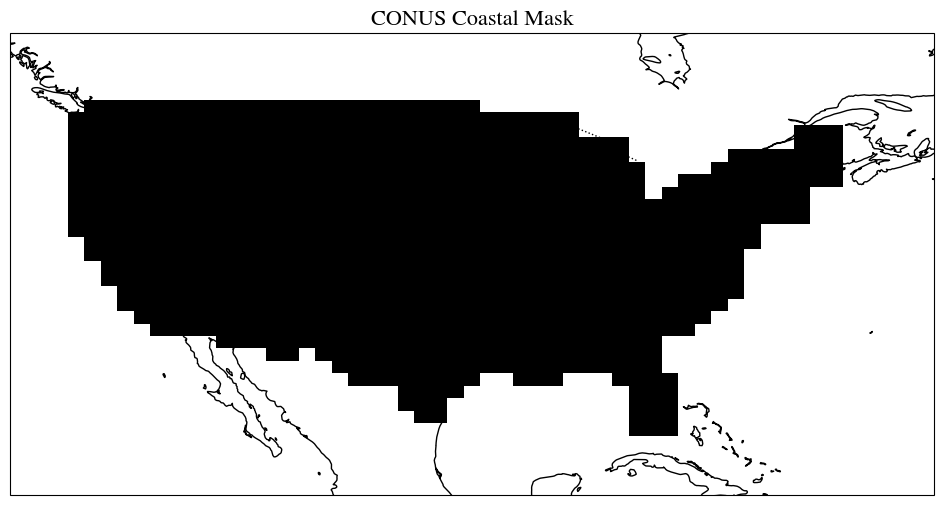

In [131]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
mask_da_loaded.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='gray_r', add_colorbar=False)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title("CONUS Coastal Mask", fontsize=16)
ax.set_extent([-130, -60, 20, 55], crs=ccrs.PlateCarree())  # Zoom to US
plt.grid(True)
plt.show()


In [132]:
### Read in original emissions data
Original_diri = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/approx2022/'

CONUSlandMasked_diri = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/'

In [153]:
### Locate aircraft emissions fires
aircraft_emisfiles = [
# 'emissions-cmip6_SO2_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
'emissions-cmip6_num_bc_a4_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
'emissions-cmip6_bc_a4_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
# 'emissions-cmip6_NO2_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc',
]

In [154]:
targetspc_ls = species_names
timeslice_start = '2021-11-30T00:00:00.000000000'
timeslice_end = '2024-01-30T00:00:00.000000000'

for spc_fileIN in aircraft_emisfiles:   
    spc_fileINpath = f'{Original_diri}{spc_fileIN}'
    # Open dataset
    spci_ds = xr.open_dataset(spc_fileINpath)

    # Subset by time if needed
    if "time" in spci_ds.dims:
        spci_ds = spci_ds.sel(time=slice(timeslice_start, timeslice_end))

    # Apply CONUS land mask (mask_da_loaded is True over CONUS land)
    # Replace masked values with zero instead of NaN
    if "emiss_aircraft" in spci_ds:
        sum_masked = spci_ds["emiss_aircraft"].where(~mask_da_loaded, other=0)
        spci_ds["emiss_aircraft"] = sum_masked
    elif "num_bc_a4_aircraft" in spci_ds:
        sum_masked = spci_ds["num_bc_a4_aircraft"].where(~mask_da_loaded, other=0)
        spci_ds["num_bc_a4_aircraft"] = sum_masked
    else:
        raise ValueError(f"'Check for the valid variable name in {spc_fileINpath}")

    # Generate species name from filename if not explicitly passed
    spc = None
    for candidate in targetspc_ls:
        if candidate in spc_fileINpath:
            spc = candidate
            break
    if spc is None:
        raise ValueError(f"Could not match species name in: {spc_fileINpath}")

    # Save to output
    spc_fileOUTpath = f"{CONUSlandMasked_diri}{spc_fileIN}"
    spci_ds.to_netcdf(spc_fileOUTpath)
    
    print("Saved to:", spc_fileOUTpath)
    print("**********************************************************")


Saved to: /net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/emissions-cmip6_num_bc_a4_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc
**********************************************************
Saved to: /net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/cams/CAMS-GLOB-ANT_v6.2/ne30np4_CONUSlandMasked_c20250619/emissions-cmip6_bc_a4_aircraft_vertical_to2022use2015_0.9x1.25_c20170608.nc
**********************************************************


In [152]:
spci_ds

<xarray.Dataset> Size: 72MB
Dimensions:             (lon: 288, lat: 192, altitude: 25, altitude_int: 26,
                         time: 13)
Coordinates:
  * lon                 (lon) float32 1kB 0.0 1.25 2.5 ... 356.2 357.5 358.8
  * lat                 (lat) float32 768B -90.0 -89.06 -88.12 ... 89.06 90.0
  * altitude            (altitude) float32 100B 0.305 0.915 ... 14.34 14.94
  * altitude_int        (altitude_int) float32 104B 0.0 0.61 ... 14.64 15.25
  * time                (time) datetime64[ns] 104B 2021-12-16 ... 2022-12-16
Data variables:
    num_bc_a4_aircraft  (time, altitude, lat, lon) float32 72MB ...
    date                (time) int64 104B ...
Attributes:
    data_title:        Emissions of num_bc_a4_aircraft for CESM-MAM4 CMIP6
    molecular_weight:  1.0
    data_creator:      Jean-Francois Lamarque (lamar@ucar.edu) and Louisa Emm...
    data_summary:      Emissions of number of particles for corresponding aer...
    cesm_contact:      Louisa Emmons or Simone Tilmes
    creation_date:     20170608
    update_date:       20170615
    history:           Original aerosol file: /glade/p/cesm/chwg_dev/emmons/C...
    data_script:       /glade/u/home/emmons/CMIP6/emissions/make_emis_cmip6_m...
    data_source_url:   http://www.globalchange.umd.edu/ceds/ceds-cmip6-data/
    data_reference:    Number calculations described in X.Liu et al., GMD, 2012.

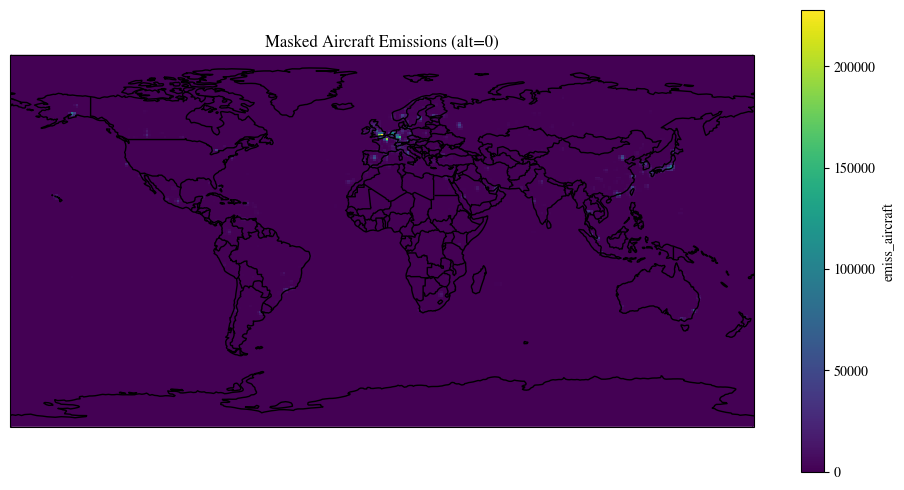

In [148]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select 2D slice from DataArray, not Dataset
plotda = spci_ds['emiss_aircraft'].isel(altitude=0,time=1)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
plotda.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', cbar_kwargs={"label": "emiss_aircraft"})
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.set_title("Masked Aircraft Emissions (alt=0)")
plt.show()


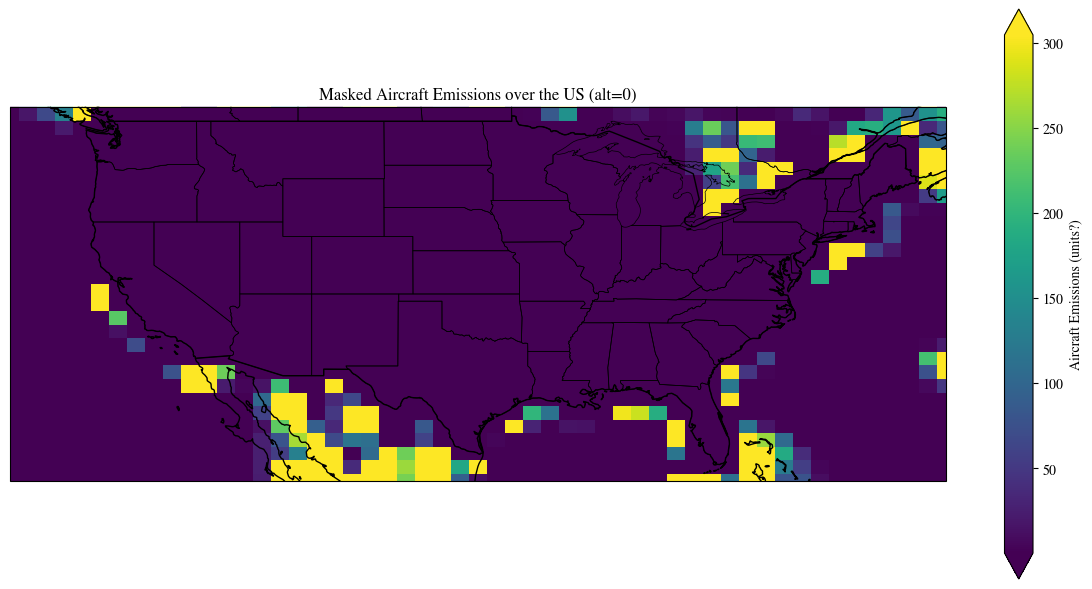

In [149]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select 2D slice from DataArray
plotda = spci_ds['emiss_aircraft'].isel(altitude=0, time=1)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to CONUS: [west, east, south, north]
ax.set_extent([-130, -65, 24, 50], crs=ccrs.PlateCarree())

# Plot with better color normalization (log or custom range for contrast)
plotda.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    vmin=plotda.where(plotda > 0).quantile(0.05),  # optional: cut off very low values
    vmax=plotda.quantile(0.95),                    # optional: cut off high outliers
    cbar_kwargs={"label": "Aircraft Emissions (units?)"}
)

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.set_title("Masked Aircraft Emissions over the US (alt=0)")

plt.tight_layout()
plt.show()


# Remove Biomass Burning emissions over CONUS Box-land